<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/rnn_lstm_gru/experiment_rnn_lstm_time_series_forecasting_progressive_levels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beginner RNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    SimpleRNN,
    Dense
)

Create Time-Series Data

In [2]:
data = np.sin(
    np.linspace(0, 100, 1000)
)

Create Sequences

In [3]:
sequence_length = 20

X = []
y = []

for i in range(
    len(data) - sequence_length
):

    X.append(
        data[i:i + sequence_length]
    )

    y.append(
        data[i + sequence_length]
    )

X = np.array(X)

y = np.array(y)

Reshape for RNN

RNN input shape:

(samples, timesteps, features)

In [4]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

Build Basic RNN

In [5]:
model = Sequential()

model.add(
    SimpleRNN(
        32,
        activation="tanh",
        input_shape=(20, 1)
    )
)

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile Model

In [6]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Train Model

In [7]:
history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0409
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1972e-04
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2089e-04
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2214e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5381e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0318e-04
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3647e-05
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8026e-05
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1751e-05


Predict

In [8]:
predictions = model.predict(X)

print(predictions[:5])

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
[[0.8997   ]
 [0.8534174]
 [0.802342 ]
 [0.7452502]
 [0.6806953]]


# Intermediate LSTM

In [9]:
from tensorflow.keras.layers import LSTM

Build LSTM Model

In [10]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(20, 1)
    )
)

model.add(Dense(1))

Compile

In [11]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Train

In [12]:
history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=32
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1562
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7825e-04
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2429e-04
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2557e-05
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1966e-05
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6492e-05
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0349e-05
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9625e-05
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0229e-05
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3388e-05
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.3518e-06
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0307e-06
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9187e-06
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━

# Advanced Stacked LSTM

In [13]:
from tensorflow.keras.layers import Dropout

model = Sequential()

# ====================================================
# LSTM BLOCK 1
# ====================================================

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(20, 1)
    )
)

model.add(Dropout(0.2))

# ====================================================
# LSTM BLOCK 2
# ====================================================

model.add(
    LSTM(64)
)

model.add(Dropout(0.2))

# ====================================================
# OUTPUT
# ====================================================

model.add(Dense(1))

compile

In [14]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Train

In [15]:
history = model.fit(
    X,
    y,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.2167 - val_loss: 0.0459
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0245 - val_loss: 3.6362e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0109 - val_loss: 6.3278e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068 - val_loss: 0.0010
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0054 - val_loss: 8.2711e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0052 - val_loss: 6.9893e-04
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046 - val_loss: 2.6449e-04
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - val_loss: 2.9149e-04
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - val_loss: 4.0783e-04
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041 - val_loss: 7.1400e-04
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - val_loss: 3.1845e-04
Epoch 12/30
13/13 ━━━━━━━━━

# Production-Level Time-Series Forecasting

In [16]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

Scale Data

In [17]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(
    data.reshape(-1, 1)
)

Create Sequences

In [18]:
sequence_length = 50

X = []
y = []

for i in range(
    len(data_scaled) - sequence_length
):

    X.append(
        data_scaled[
            i:i + sequence_length
        ]
    )

    y.append(
        data_scaled[
            i + sequence_length
        ]
    )

X = np.array(X)

y = np.array(y)

Train-Test Split

In [19]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Build Production LSTM

In [20]:
model = Sequential()

# ====================================================
# BLOCK 1
# ====================================================

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(50, 1)
    )
)

model.add(Dropout(0.3))

# ====================================================
# BLOCK 2
# ====================================================

model.add(
    LSTM(
        64,
        return_sequences=True
    )
)

model.add(Dropout(0.3))

# ====================================================
# BLOCK 3
# ====================================================

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

# ====================================================
# DENSE
# ====================================================

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile

In [21]:
model.compile(
    optimizer="adam",
    loss="mse"
)

Callbacks

In [22]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
)

Train

In [23]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=100,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.1614 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0311 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0139 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0094 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0074 - val_loss: 1.1130e-04 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0072 - val_loss: 5.4182e-04 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0063 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0070 - val_loss: 3.3553e-04 - learning_rate: 0.0010
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0059 - val_loss: 3.6491e-04 - learning_rate: 0

Predictions

In [24]:
predictions = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


Inverse Scaling

In [25]:
predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

Visualize Forecast

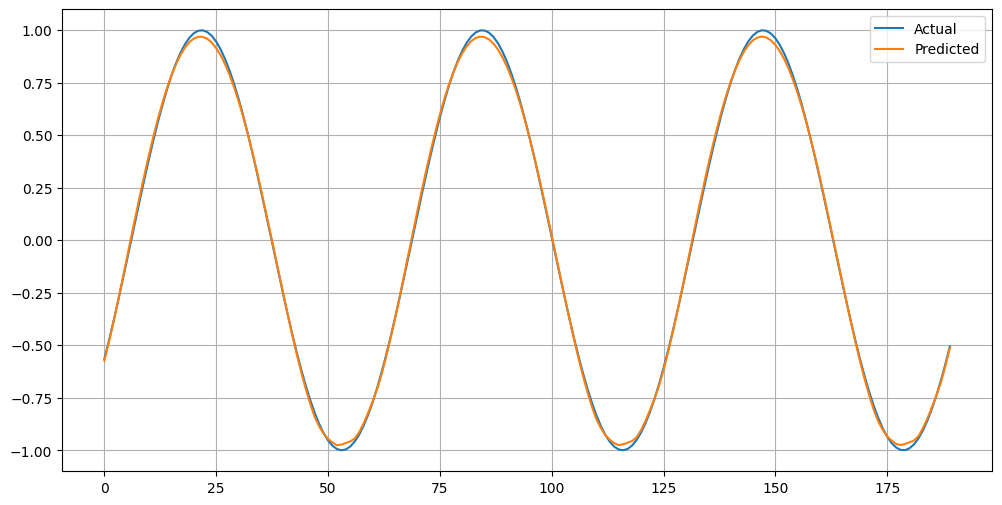

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.grid(True)

plt.show()